# Notebook for constructing age models for the Mamainse Point Volcanics

In [6]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section (lower R1 pole) is > ca. 1107 Ma, let's set it to be 1110 Ma which is thought to be the beginnin of the Midcontinent Rift
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as one constraint at strat height 2000
- The top of the section is of normal polarity with no radiometric constraints, let's set it to be 1090 $\pm$ 4 Ma

In [7]:
Mamainse_Name = ("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Mamainse_Age           = [ 1110, 1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 2/2,     0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0,     2000,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "./Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2000.0, 4100.0], [0.01, 0.01, 0.01], [1110.0, 1100.36, 1090.0], [1.0, 0.125, 2.0], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "./Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [8]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1110.0568961234787, 1109.9895395976262, 1109.9550627469173, 1109.9085162953268, 1109.8659422562441, 1109.820773812549, 1109.7494382066513, 1109.7086122486412, 1109.6566656093323, 1109.6034116073906  …  1090.4262827824264, 1090.3876598393072, 1090.3360927466629, 1090.2813295553153, 1090.2483560943638, 1090.1967617352323, 1090.1562140993715, 1090.1078874619366, 1090.058949510042, 1090.011107228752], [0.9096489714497663, 0.9981845375292356, 1.0121171888906189, 1.0387021290287128, 1.083636166979911, 1.1135622111537156, 1.1737195619773209, 1.1978660508962564, 1.2362929950735426, 1.2636333769352273  …  1.6601979264322466, 1.6513839438423819, 1.6391357664231674, 1.6049141306929373, 1.5954502111797169, 1.5869401607342148, 1.5634791760748337, 1.5323594477936964, 1.5245184609210995

### posterior summary age model

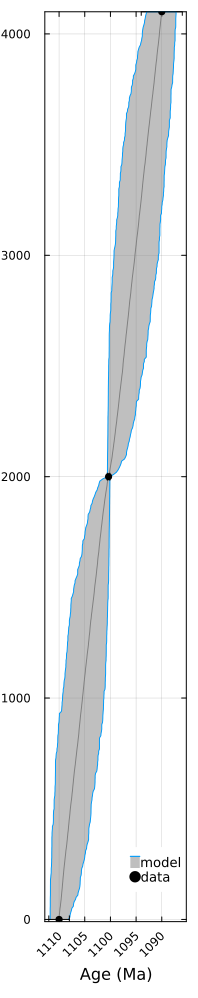

In [9]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 4100))
# savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

  0.006447 seconds (17.00 k allocations: 13.748 MiB, 48.70% gc time)


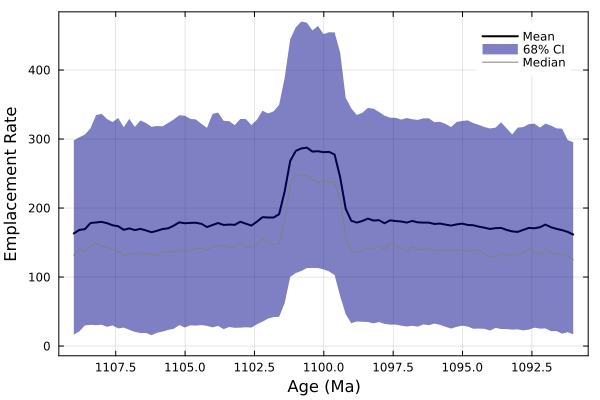

In [10]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, save_figure=false)

### example posterior age models

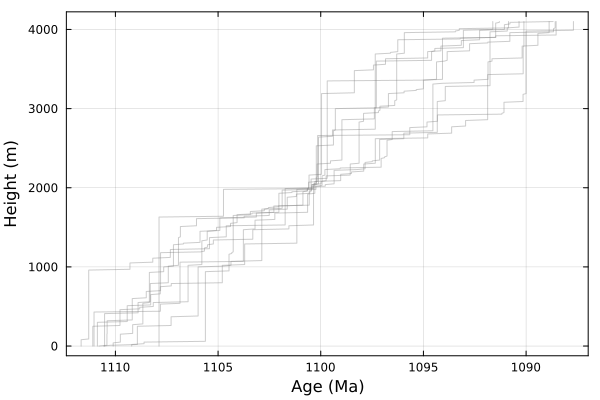

In [11]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [12]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1110.44,1110.43,1111.11,1110.77,1108.95,1110.3,1110.56,1111.48,1109.41,1107.98,1109.34,1109.34,1110.52,1110.78,1111.5,1111.1,1109.13,1110.06,1108.87,1110.15,1108.3,1110.99,1109.78,1109.45,1108.74,1111.06,1109.3,1109.11,1109.69,1111.67,1111.26,1108.3,1109.74,1110.25,1111.62,1110.77,1110.48,1109.21,1110.79,1109.49,1111.17,1110.36,1110.13,1110.18,1110.29,1109.72,1109.32,1112.26,1110.95,1111.22,1110.12,1108.88,1110.28,1108.75,1109.79,1109.95,1110.21,1109.82,1109.57,1110.13,1111.69,1110.91,1110.91,1109.58,1110.43,1111.28,1110.71,1109.38,1109.93,1109.93,1108.58,1109.5,1110.54,1109.27,1109.89,1109.67,1111.34,1111.1,1111.02,1109.94,1111.11,1109.44,1109.93,1110.12,1109.09,1110.55,1110.15,1111.28,1110.35,1111.96,1110.08,1110.26,1110.52,1111.65,1107.75,1110.61,1109.16,1108.67,1111.47,⋯
2,10.0,1110.44,1110.43,1111.11,1110.77,1108.95,1110.3,1108.42,1111.14,1109.41,1106.81,1109.34,1109.34,1110.52,1110.78,1111.5,1111.1,1109.13,1110.06,1108.87,1110.15,1108.3,1110.99,1109.78,1109.45,1108.74,1111.06,1109.3,1109.11,1109.69,1111.67,1111.26,1108.3,1109.74,1110.25,1111.62,1110.77,1110.48,1109.21,1110.79,1109.49,1111.17,1110.36,1110.13,1110.18,1110.29,1109.72,1106.67,1112.26,1110.95,1111.22,1110.12,1108.88,1110.28,1108.75,1109.79,1109.95,1110.21,1109.35,1109.57,1110.13,1111.69,1110.91,1110.91,1109.58,1110.43,1111.28,1110.71,1109.38,1109.93,1109.93,1108.58,1109.5,1110.54,1107.83,1109.89,1109.67,1106.81,1111.1,1111.02,1109.94,1111.11,1109.44,1109.93,1110.12,1109.09,1110.55,1110.15,1111.28,1110.35,1111.96,1110.08,1110.26,1110.52,1111.65,1107.75,1110.61,1109.16,1108.67,1111.47,⋯
3,20.0,1110.44,1110.43,1111.11,1110.77,1108.95,1110.3,1108.42,1110.07,1109.41,1106.81,1109.34,1109.34,1110.52,1110.78,1111.5,1111.1,1109.13,1110.06,1108.87,1110.15,1108.3,1110.99,1109.78,1109.45,1108.74,1111.06,1109.3,1109.11,1109.69,1111.67,1111.26,1108.3,1109.74,1110.25,1111.62,1110.77,1110.34,1109.21,1110.79,1109.49,1111.17,1110.36,1110.13,1110.18,1110.29,1109.72,1106.67,1112.26,1110.95,1111.22,1110.12,1108.88,1110.28,1108.75,1109.79,1109.95,1110.21,1109.35,1109.57,1110.13,1111.69,1110.91,1110.91,1109.58,1110.05,1111.28,1110.71,1109.38,1109.93,1109.93,1108.58,1108.82,1110.1,1107.83,1109.89,1109.67,1106.81,1111.1,1111.02,1109.94,1111.11,1109.44,1109.93,1110.12,1109.09,1110.55,1110.15,1111.28,1110.35,1111.96,1110.08,1110.26,1110.52,1111.65,1107.75,1110.61,1109.16,1108.67,1111.47,⋯
4,30.0,1109.77,1110.43,1111.11,1110.77,1108.95,1110.3,1108.42,1110.07,1109.41,1106.81,1109.34,1109.34,1110.52,1110.78,1111.5,1110.22,1108.75,1110.06,1108.87,1110.15,1108.3,1110.99,1109.78,1109.45,1108.74,1111.06,1109.3,1109.11,1109.69,1111.67,1111.26,1108.3,1109.74,1110.25,1111.62,1110.77,1110.34,1109.21,1110.79,1109.49,1111.17,1110.36,1110.13,1110.18,1110.29,1109.72,1106.67,1112.26,1110.95,1111.22,1110.12,1106.33

In [13]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"./Mamainse_Point_Volcanic_Group_posterior_ages.csv"